In [4]:
import torch
from torch import nn
from d2l import torch as d2l

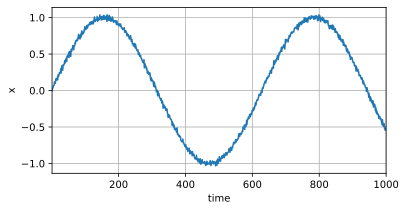

In [5]:
T = 1000
time = torch.arange(1, T+1, dtype=torch.float32)
# normal 生成正态分布（高斯分布）随机数  
x = torch.sin(0.01 * time) + torch.normal(0, 0.02, (T,))
d2l.plot(time, [x], 'time', 'x', xlim=[1, 1000], figsize=(6, 3))

In [6]:
tau = 4
features = torch.zeros((T - tau, tau))
for i in range(tau):
    features[:,i] = x[i: T - tau + i]
labels = x[tau:].reshape((-1,1))
batch_size, n_train = 16, 600
train_iter = d2l.load_array((features[:n_train], labels[:n_train]),
                            batch_size, is_train=True)

In [7]:
def init_weights(m):
    if type(m) == nn.Linear:
        # xavier_uniform_：均匀分布，区间取值，稳定、默认首选
        # xavier_normal_：正态分布，中间密两边疏，特殊场景使用
        nn.init.xavier_uniform_(m.weight)
        
def get_net():
    net = nn.Sequential(nn.Linear(4,10),
                        nn.ReLU(),
                        nn.Linear(10,1))
    net.apply(init_weights)
    return net

# 平方损失。注意：MSELoss计算平方误差时不带系数1/2
loss = nn.MSELoss(reduction='none')

In [8]:
def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr)
    for epoch in range(epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.sum().backward()
            trainer.step()
        print(f'epoch {epoch + 1}, '
              f'loss: {d2l.evaluate_loss(net, train_iter, loss):f}')

net = get_net()
train(net, train_iter, loss, 5, 0.01) 

epoch 1, loss: 0.005802
epoch 2, loss: 0.001493
epoch 3, loss: 0.001298
epoch 4, loss: 0.001217
epoch 5, loss: 0.001180


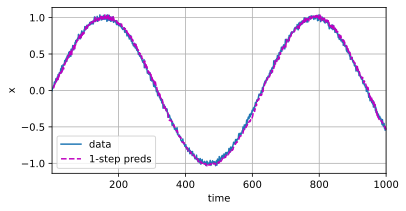

In [9]:
onestep_preds = net(features)
d2l.plot([time, time[tau:]],
         [x.detach().numpy(), onestep_preds.detach().numpy()], 'time',
         'x', legend=['data', '1-step preds'], xlim=[1, 1000],
         figsize=(6, 3))